In [18]:
# 1. Standard Library
import random
from tqdm import tqdm

# 2. Data Manipulation & Numerical Computing
import numpy as np
import pandas as pd

# 3. Machine Learning & Preprocessing
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    brier_score_loss,
    f1_score,
    classification_report,
    confusion_matrix
)

# 4. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

In [19]:
df = pd.read_csv('final.csv')

### Spearman's Correlation Matrix

In [20]:
# Calculate the correlation matrix
correlation_matrix = df.corr(method='spearman')

In [21]:
df.columns

Index(['tourney_id', 'tourney_name', 'surface', 'draw_size', 'tourney_level',
       'tourney_date', 'best_of', 'round', 'player_1_id', 'player_1_name',
       'player_1_hand', 'player_1_ht', 'player_1_ioc', 'player_1_age',
       'player_1_rank', 'player_1_rank_points', 'player_2_id', 'player_2_name',
       'player_2_hand', 'player_2_ht', 'player_2_ioc', 'player_2_age',
       'player_2_rank', 'player_2_rank_points', 'result', 'p1_win_streak',
       'p2_win_streak', 'p1_lose_streak', 'p2_lose_streak', 'p1_surface_wr',
       'p2_surface_wr', 'p1_titles', 'p2_titles', 'rank_diff', 'rank_diff_abs',
       'rank_rel', 'age_diff', 'height_diff', 'win_streak_diff',
       'lose_streak_diff', 'surface_wr_diff', 'titles_diff'],
      dtype='object')

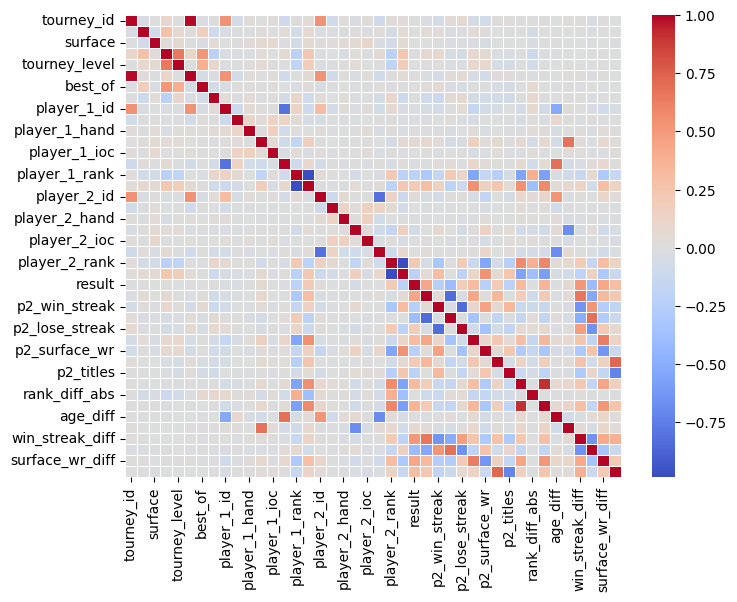

In [22]:
# Set the size of the plot
plt.figure(figsize=(8, 6))

# Create the heatmap
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar=True
)

#plt.title('Feature Correlation Matrix')
plt.show()

In [23]:
# Get the correlations of all features against 'Price'
result_correlations = correlation_matrix['result'].sort_values(ascending=False)

print(result_correlations[:8])
print(result_correlations[-5:])

result             1.000000
win_streak_diff    0.512831
p1_win_streak      0.444510
surface_wr_diff    0.428829
rank_rel           0.362046
rank_diff          0.319179
p1_surface_wr      0.314880
titles_diff        0.295758
Name: result, dtype: float64
player_1_rank      -0.212891
p2_surface_wr      -0.236545
p2_win_streak      -0.244722
p1_lose_streak     -0.396556
lose_streak_diff   -0.408858
Name: result, dtype: float64


### Sorting according to `tourney_date`

In [24]:
# This compares row position n with row position n-1
for n in range(1, len(df)):
    current_val = df['tourney_date'].iloc[n]
    prev_val = df['tourney_date'].iloc[n-1]

    if current_val < prev_val:
        print(f"Error at position {n}: {prev_val} comes before {current_val}")

Error at position 8770: 20171124 comes before 20171106
Error at position 8786: 20171106 comes before 20170922
Error at position 11684: 20181123 comes before 20180921
Error at position 14306: 20191121 comes before 20191120
Error at position 14310: 20191120 comes before 20191118
Error at position 14320: 20191121 comes before 20191119
Error at position 14324: 20191120 comes before 20191118
Error at position 14328: 20191121 comes before 20191120
Error at position 14330: 20191120 comes before 20191119
Error at position 14332: 20191119 comes before 20191118
Error at position 14340: 20191122 comes before 20191121
Error at position 14344: 20191124 comes before 20191123
Error at position 14346: 20191123 comes before 20191122
Error at position 14350: 20191123 comes before 20191122
Error at position 14352: 20191122 comes before 20190913
Error at position 14364: 20190914 comes before 20190913
Error at position 14380: 20190914 comes before 20190913
Error at position 14398: 20190914 comes before 201

In [25]:
df_sorted = df.sort_values(by='tourney_date').copy()

# This compares row position n with row position n-1
for n in range(1, len(df_sorted)):
    current_val = df_sorted['tourney_date'].iloc[n]
    prev_val = df_sorted['tourney_date'].iloc[n-1]

    if current_val < prev_val:
        print(f"Error at position {n}: {prev_val} comes before {current_val}")

In [26]:
df_sorted.reset_index(drop=True, inplace=True)

### Baseline - coin flip:

In [27]:
X = df.drop('result', axis=1)
y = df['result']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


coin_flip = []
for i in range(len(y_test)):
  coin_flip.append(random.choice([0,1]))

y_test_arr = np.array(y_test)

accurate = 0

for i in range(len(y_test_arr)):
  if y_test_arr[i] == coin_flip[i]:
    accurate += 1

print(f'Presnoť: {accurate / len(y_test_arr):.2f}')

Presnoť: 0.51


### Training Loop Definition

In [28]:
# 1. Setup Data
X = df_sorted.drop('result', axis=1)
y = df_sorted['result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --- 2. METRICS FUNCTION ---
def get_metrics(y_true, y_probs, threshold=0.5):
    y_pred = (y_probs >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'log_loss': log_loss(y_true, y_probs),
        'f1': f1_score(y_true, y_pred),
        'threshold': threshold
    }


# 2. Define the TimeSeriesSplit
# This creates folds where the training set grows over time
tscv = TimeSeriesSplit(n_splits=10)



# --- 3. XGBOOST GRID SEARCH ---
print("Running XGBoost Grid Search...")
xgb_param_grid = {
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'gamma': [0.1, 0.2],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [100, 200]
}

# 3. Use this 'tscv' object inside your GridSearchCV
xgb_grid = GridSearchCV(
    xgb.XGBClassifier(objective='binary:logistic', random_state=42),
    param_grid=xgb_param_grid,
    cv=tscv,
    scoring='neg_log_loss',
    n_jobs=-1
)

xgb_grid.fit(X_train, y_train)

# --- 4. LOGISTIC REGRESSION GRID SEARCH ---
print("Running Logistic Regression Grid Search...")
# We use a Pipeline to ensure scaling happens inside the cross-validation folds
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000))
])

lr_param_grid = {
    'lr__C': [0.01, 0.1, 1.0, 10.0], # Regularization strength
    'lr__penalty': ['l2']           # lbfgs solver only supports l2 or None
}

lr_grid = GridSearchCV(
    lr_pipe,
    param_grid=lr_param_grid,
    cv=tscv,
    scoring='neg_log_loss'
)

lr_grid.fit(X_train, y_train)

Running XGBoost Grid Search...


Running Logistic Regression Grid Search...


,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'lr__C': [0.01, 0.1, ...], 'lr__penalty': ['l2']}"
,scoring,'neg_log_loss'
,n_jobs,None
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [29]:
# This is how are the data split for testing

tscv = TimeSeriesSplit(n_splits=10)

for i, (train_index, test_index) in enumerate(tscv.split(X_test)):
    print(f"Fold {i}:")
    print(f"  Train: index {train_index[0]} to {train_index[-1]}")
    print(f"  Test:  index {test_index[0]} to {test_index[-1]}")

Fold 0:
  Train: index 0 to 435
  Test:  index 436 to 871
Fold 1:
  Train: index 0 to 871
  Test:  index 872 to 1307
Fold 2:
  Train: index 0 to 1307
  Test:  index 1308 to 1743
Fold 3:
  Train: index 0 to 1743
  Test:  index 1744 to 2179
Fold 4:
  Train: index 0 to 2179
  Test:  index 2180 to 2615
Fold 5:
  Train: index 0 to 2615
  Test:  index 2616 to 3051
Fold 6:
  Train: index 0 to 3051
  Test:  index 3052 to 3487
Fold 7:
  Train: index 0 to 3487
  Test:  index 3488 to 3923
Fold 8:
  Train: index 0 to 3923
  Test:  index 3924 to 4359
Fold 9:
  Train: index 0 to 4359
  Test:  index 4360 to 4795


### Training & Testing Execution

In [30]:
results_all_detailed = []
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6]
searches = [('XGBoost', xgb_grid), ('LogisticRegression', lr_grid)]

for model_name, grid in searches:
    print(f"Processing all iterations for {model_name}...")
    all_params = grid.cv_results_['params']

    # Use tqdm to track progress through hyperparameter combinations
    for i, params in enumerate(tqdm(all_params)):
        # 1. Recreate the model
        if model_name == 'XGBoost':
            current_model = xgb.XGBClassifier(**params, objective='binary:logistic', random_state=42)
        else:
            lr_params = {k.replace('lr__', ''): v for k, v in params.items()}
            current_model = Pipeline([
                ('scaler', StandardScaler()),
                ('lr', LogisticRegression(**lr_params, max_iter=1000))
            ])

        # 2. Manual OOF Cross-Validation (on X_train)
        oof_probs = []
        oof_true = []

        for train_idx, val_idx in tscv.split(X_train):
            X_f_train, X_f_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_f_train, y_f_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

            current_model.fit(X_f_train, y_f_train)
            oof_probs.extend(current_model.predict_proba(X_f_val)[:, 1])
            oof_true.extend(y_f_val)

        oof_probs = np.array(oof_probs)
        oof_true = np.array(oof_true)

        # 3. Final Test Fit
        current_model.fit(X_train, y_train)
        test_probs = current_model.predict_proba(X_test)[:, 1]

        # 4. SAVE EVERY THRESHOLD RESULT
        for t in thresholds:
            # Calculate metrics for this specific threshold on BOTH sets
            train_metrics = get_metrics(oof_true, oof_probs, threshold=t)
            test_metrics = get_metrics(y_test, test_probs, threshold=t)

            entry = {
                'model_name': model_name,
                'iteration_index': i,
                'params': str(params),
                'threshold': t,
                # Training (CV) Results
                'cv_accuracy': train_metrics['accuracy'],
                'cv_f1': train_metrics['f1'],
                'cv_log_loss': train_metrics['log_loss'],
                # Test (Hold-out) Results
                'test_accuracy': test_metrics['accuracy'],
                'test_f1': test_metrics['f1'],
                'test_log_loss': test_metrics['log_loss'],
            }
            results_all_detailed.append(entry)

# Convert to DataFrame
all_runs_df = pd.DataFrame(results_all_detailed)

Processing all iterations for XGBoost...


  0%|          | 0/32 [00:00<?, ?it/s]

100%|██████████| 32/32 [03:22<00:00,  6.33s/it]


Processing all iterations for LogisticRegression...


100%|██████████| 4/4 [00:06<00:00,  1.66s/it]


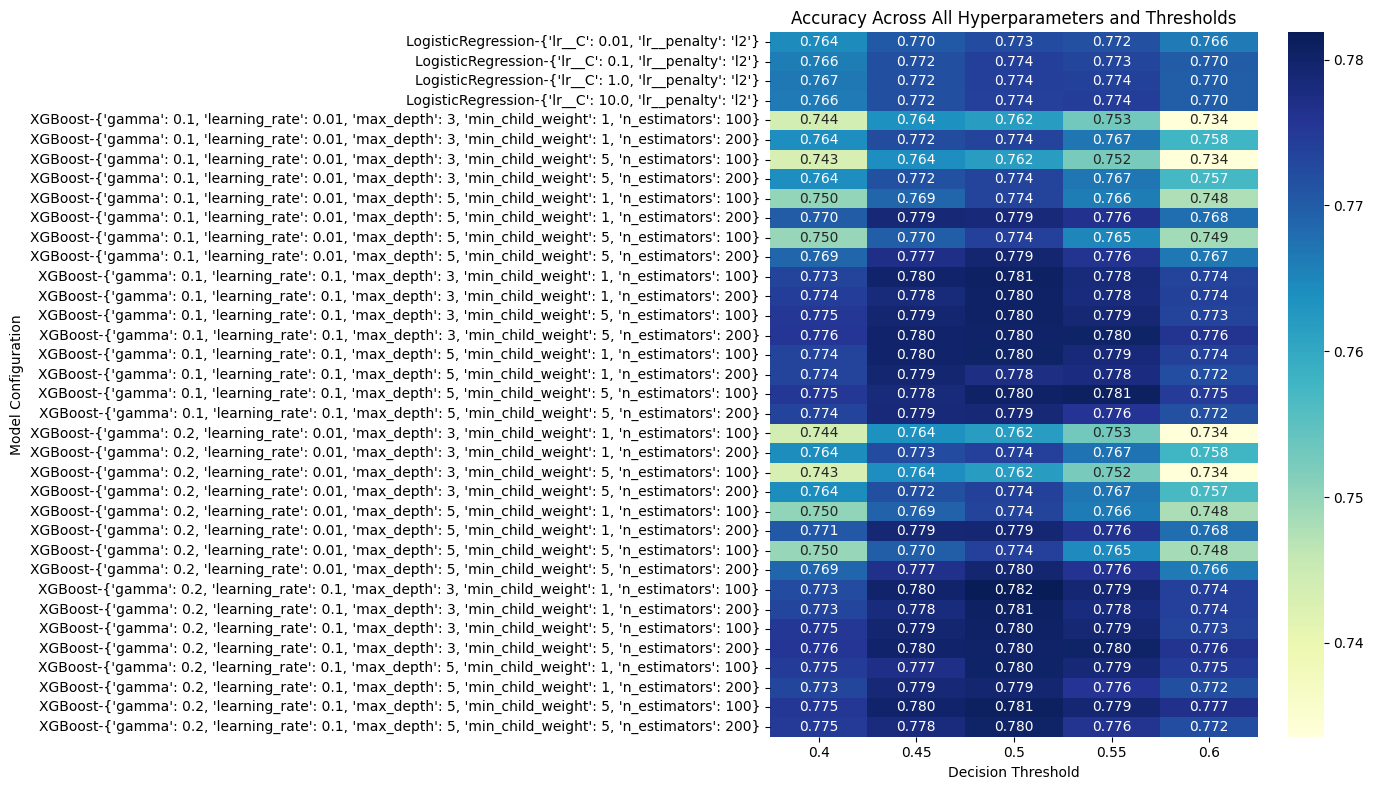

In [31]:
# We'll pivot the data to see Model/Params vs Threshold
# Let's look at Accuracy for this example
pivot_df = all_runs_df.pivot_table(
    index=['model_name', 'params'],
    columns='threshold',
    values='cv_accuracy'
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title('Accuracy Across All Hyperparameters and Thresholds')
plt.ylabel('Model Configuration')
plt.xlabel('Decision Threshold')
plt.tight_layout()
plt.show()

### Best Model Selection

In [32]:
def find_3d_pareto(df):
    # Ensure our 'Higher is Better' metric exists
    df['cv_log_loss_inv'] = 1 - df['cv_log_loss']

    # Selection criteria: Accuracy, F1, and Inverse Log Loss
    cols = ['cv_accuracy', 'cv_f1', 'cv_log_loss_inv']
    data = df[cols].values
    pareto_indices = []

    for i, c1 in enumerate(data):
        is_dominated = False
        for j, c2 in enumerate(data):
            if i == j: continue
            # If c2 is better or equal in all AND strictly better in at least one
            if np.all(c2 >= c1) and np.any(c2 > c1):
                is_dominated = True
                break
        if not is_dominated:
            pareto_indices.append(i)

    return df.iloc[pareto_indices].copy()

pareto_3d_df = find_3d_pareto(all_runs_df)

# Display the table with parameters
# Note: 'params' column contains the hyperparameters from your GridSearch
pareto_summary = pareto_3d_df[[
    'model_name', 'threshold', 'cv_accuracy', 'cv_f1', 'cv_log_loss', 'params'
]].sort_values(by='cv_accuracy', ascending=False)

print("--- 3D Pareto Front Models & Parameters ---")
display(pareto_summary)

--- 3D Pareto Front Models & Parameters ---


,model_name,threshold,cv_accuracy,cv_f1,cv_log_loss,params
122,XGBoost,0.50,0.781870,0.780738,0.454264,"{'gamma': 0.2, 'learning_rate': 0.1, 'max_dept..."
152,XGBoost,0.50,0.780895,0.780807,0.454382,"{'gamma': 0.2, 'learning_rate': 0.1, 'max_dept..."
151,XGBoost,0.45,0.779977,0.787051,0.454382,"{'gamma': 0.2, 'learning_rate': 0.1, 'max_dept..."
61,XGBoost,0.45,0.779920,0.787196,0.455066,"{'gamma': 0.1, 'learning_rate': 0.1, 'max_dept..."
121,XGBoost,0.45,0.779805,0.786469,0.454264,"{'gamma': 0.2, 'learning_rate': 0.1, 'max_dept..."
56,XGBoost,0.45,0.779805,0.787298,0.455322,"{'gamma': 0.1, 'learning_rate': 0.1, 'max_dept..."
136,XGBoost,0.45,0.779805,0.787298,0.455322,"{'gamma': 0.2, 'learning_rate': 0.1, 'max_dept..."
135,XGBoost,0.40,0.775502,0.790469,0.455322,"{'gamma': 0.2, 'learning_rate': 0.1, 'max_dept..."
55,XGBoost,0.40,0.775502,0.790469,0.455322,"{'gamma': 0.1, 'learning_rate': 0.1, 'max_dept..."
50,XGBoost,0.40,0.775445,0.790404,0.455246,"{'gamma': 0.1, 'learning_rate': 0.1, 'max_dept..."


In [33]:
fig = go.Figure()

# 1. Plot all runs as small, semi-transparent points
fig.add_trace(go.Scatter3d(
    x=all_runs_df['cv_log_loss_inv'],
    y=all_runs_df['cv_f1'],
    z=all_runs_df['cv_accuracy'],
    mode='markers',
    marker=dict(size=3, color='blue', opacity=0.3),
    name='All Configurations'
))

# 2. Plot the Pareto Frontier points
fig.add_trace(go.Scatter3d(
    x=pareto_3d_df['cv_log_loss_inv'],
    y=pareto_3d_df['cv_f1'],
    z=pareto_3d_df['cv_accuracy'],
    mode='markers+text',
    marker=dict(
        size=8,
        color=pareto_3d_df['model_name'].map({'XGBoost': 'orange', 'LogisticRegression': 'blue'}),
        symbol='diamond',
        line=dict(color='black', width=2)
    ),
    name='Pareto Candidates',
    text=pareto_3d_df['model_name'],
    hovertemplate="<b>%{text}</b><br>" +
                  "Inv LogLoss: %{x:.4f}<br>" +
                  "F1: %{y:.4f}<br>" +
                  "Accuracy: %{z:.4f}<br>" +
                  "<extra></extra>"
))

fig.update_layout(
    title="3D Tennis Model Optimization",
    scene=dict(
        xaxis_title='1 - Log Loss (Calibration)',
        yaxis_title='F1-Score (Balance)',
        zaxis_title='Accuracy (Success Rate)'
    ),
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

### 🎾 Strategic Model Selection: Choosing Your Winner
Depending on your specific use case for this tennis model, you should prioritize different dimensions of the 3D Pareto Front. Use the table below to identify which model configuration aligns with your strategy:

| If your goal is... | Prioritize this Axis | Why? |
| :--- | :--- | :--- |
| **Betting / ROI** | **$1 - \text{LogLoss}$** | • Requires precise, well-calibrated probabilities.<br>• Essential for identifying "value" gaps against bookmaker odds. |
| **Tournament Brackets** | **Accuracy** | • Focuses on binary outcomes.<br>• You simply need to know who walks off the court as the winner. |
| **Upset Spotting** | **F1-Score** | • Balances Precision and Recall.<br>• Minimizes "False Positives" on heavy favorites to successfully catch underdogs. |

---
> **Note:** The "Best Overall" model is typically the one with the shortest **Euclidean Distance** to the ideal $(1, 1, 1)$ coordinate.

In [34]:
# Assuming pareto_3d_df exists from the previous step

# 1. Define the 'Perfect' coordinates
perfect_point = np.array([1.0, 1.0, 1.0])

# 2. Calculate distance for each candidate
def calculate_distance(row):
    model_point = np.array([
        row['cv_log_loss_inv'],
        row['cv_f1'],
        row['cv_accuracy']
    ])
    return np.linalg.norm(perfect_point - model_point)

pareto_3d_df['dist_to_perfect'] = pareto_3d_df.apply(calculate_distance, axis=1)

# 3. Find the winner
best_overall_model = pareto_3d_df.sort_values('dist_to_perfect').iloc[0]

print(f"The 'Mathematics Best' Tradeoff Model is:")
print(f"Model: {best_overall_model['model_name']}")
print(f"Params: {best_overall_model['params']}")
print(f"Distance to Perfect: {best_overall_model['dist_to_perfect']:.4f}")

print()
print(f"CV accuracy: {best_overall_model['cv_accuracy']}")
print(f"CV log_loss: {best_overall_model['cv_log_loss']}")
print(f"CV f1: {best_overall_model['cv_f1']}")

print()
print(f"Test accuracy: {best_overall_model['test_accuracy']}")
print(f"Test log_loss: {best_overall_model['test_log_loss']}")
print(f"Test f1: {best_overall_model['test_f1']}")

The 'Mathematics Best' Tradeoff Model is:
Model: XGBoost
Params: {'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100}
Distance to Perfect: 0.5479

CV accuracy: 0.7799770510613884
CV log_loss: 0.4543824998719006
CV f1: 0.7870509189849519

Test accuracy: 0.78628023352794
Test log_loss: 0.43966260371241433
Test f1: 0.7934716905097723


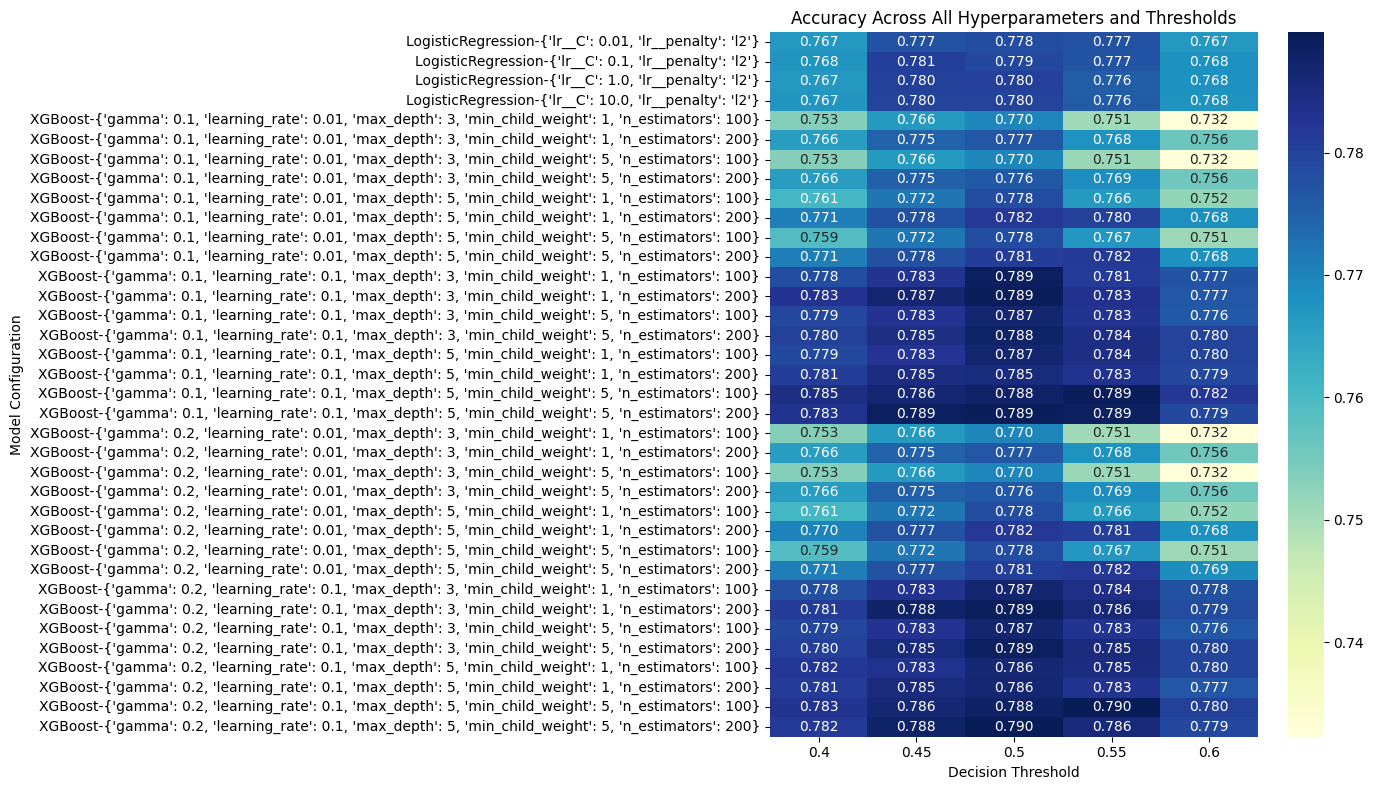

In [35]:
# We'll pivot the data to see Model/Params vs Threshold
# Let's look at Accuracy for this example
pivot_df = all_runs_df.pivot_table(
    index=['model_name', 'params'],
    columns='threshold',
    values='test_accuracy'
)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df, annot=True, cmap='YlGnBu', fmt=".3f")
plt.title('Accuracy Across All Hyperparameters and Thresholds')
plt.ylabel('Model Configuration')
plt.xlabel('Decision Threshold')
plt.tight_layout()
plt.show()

### Features Importance

In [36]:
# 1. Calculate distance to perfect (1,1,1) for EVERY model in the full dataframe
perfect_point = np.array([1.0, 1.0, 1.0])

def calc_dist(row):
    point = np.array([row['cv_log_loss_inv'], row['cv_f1'], row['cv_accuracy']])
    return np.linalg.norm(perfect_point - point)

all_runs_df['dist_to_perfect'] = all_runs_df.apply(calc_dist, axis=1)

# 2. Extract the best XGBoost and the best Logistic Regression specifically
xgb_winner = all_runs_df[all_runs_df['model_name'] == 'XGBoost'].sort_values('dist_to_perfect').iloc[0]
lr_winner = all_runs_df[all_runs_df['model_name'] == 'LogisticRegression'].sort_values('dist_to_perfect').iloc[0]

print(f"XGBoost Winner (Accuracy: {xgb_winner['cv_accuracy']:.4f})")
print(f"LogReg Winner (Accuracy: {lr_winner['cv_accuracy']:.4f})")

XGBoost Winner (Accuracy: 0.7800)
LogReg Winner (Accuracy: 0.7719)


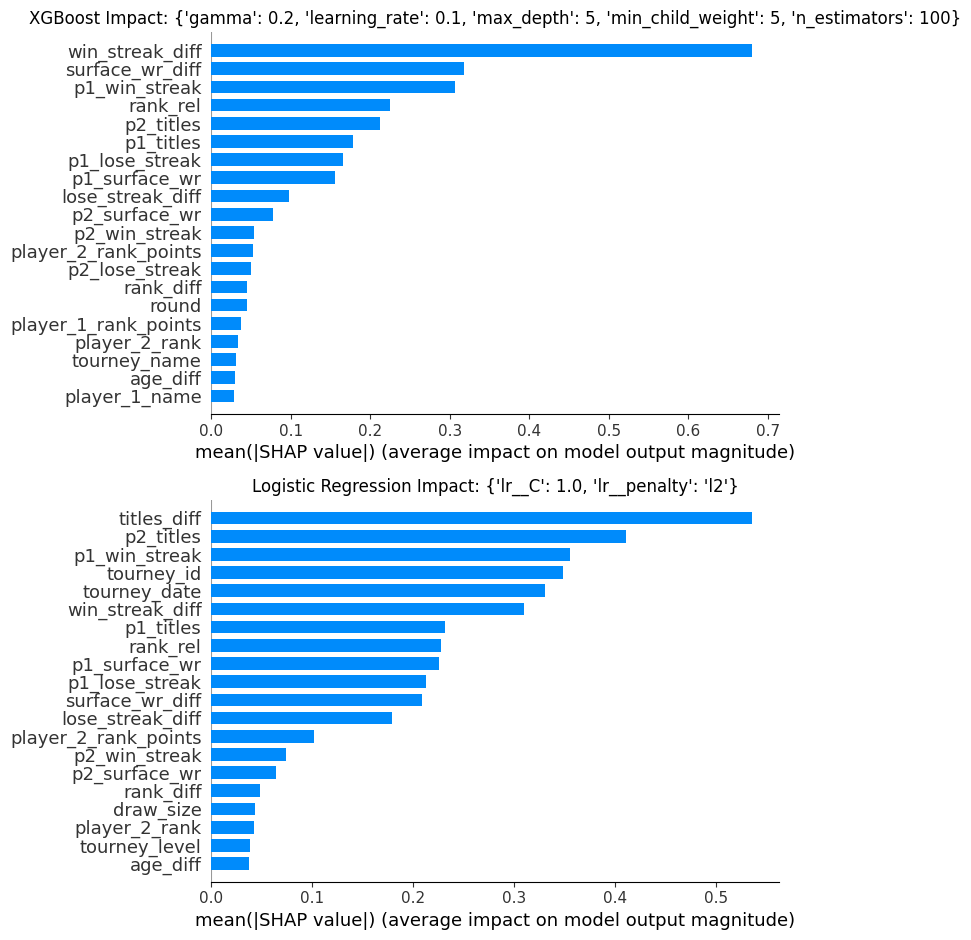

In [37]:
# --- PREP XGBOOST ---
xgb_model = xgb.XGBClassifier(**eval(xgb_winner['params'])).fit(X_train, y_train)
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_train)

# --- PREP LOGREG ---
lr_params = {k.replace('lr__', ''): v for k, v in eval(lr_winner['params']).items()}
scaler = StandardScaler().fit(X_train)
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
lr_model = LogisticRegression(**lr_params).fit(X_train_scaled, y_train)

explainer_lr = shap.LinearExplainer(lr_model, X_train_scaled)
shap_values_lr = explainer_lr.shap_values(X_train_scaled)

# --- VISUALIZE GLOBAL IMPORTANCE ---
fig, ax = plt.subplots(2, 1, figsize=(12, 20))

plt.sca(ax[0])
ax[0].set_title(f"XGBoost Impact: {xgb_winner['params']}")
shap.summary_plot(shap_values_xgb, X_train, plot_type="bar", show=False)

plt.sca(ax[1])
ax[1].set_title(f"Logistic Regression Impact: {lr_winner['params']}")
shap.summary_plot(shap_values_lr, X_train_scaled, plot_type="bar", show=False)

plt.tight_layout()
plt.show()

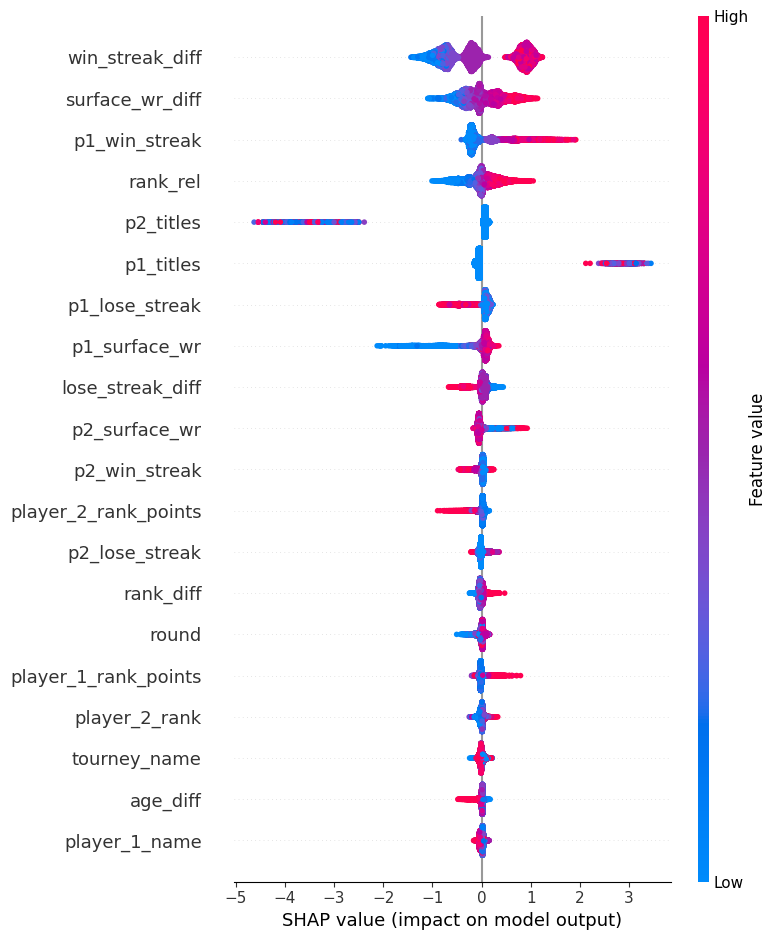

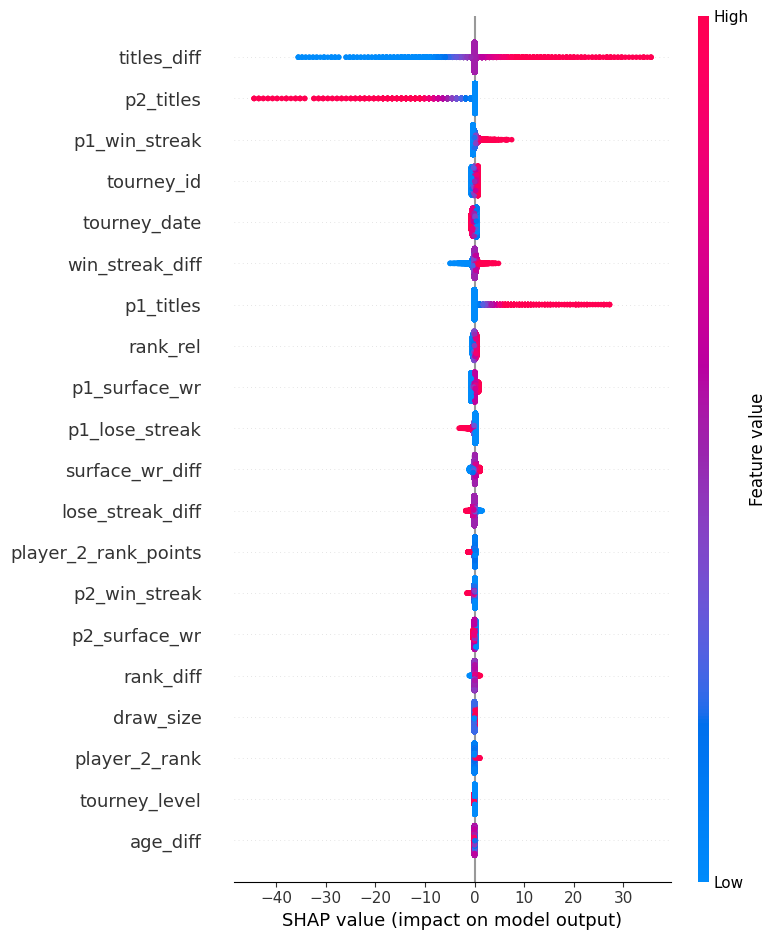

In [38]:
# Check directional impact for XGBoost
shap.summary_plot(shap_values_xgb, X_train)

# Check directional impact for Logistic Regression
shap.summary_plot(shap_values_lr, X_train_scaled)